# Compare the FTW baseline and boundary-aware model on real images

This notebook compares `ftw_mask_baseline` with
`ftw_dual_head_boundary_bce_w20_s012` on the same held-out **real FTW test images**
from Austria, Croatia, and Denmark. Evaluation explicitly disables all augmentation.

## tl;dr

Run all cells. The result cell reports whether the paired Boundary IoU improvement is
positive overall and within each country, including a bootstrap 95% confidence interval.
The image grids show the exact same real samples for both models.

## Context & Methods

### Key assumptions

- The baseline is an 8-channel mask-only U-Net; the tuned model adds the distance head and boundary-weighted loss. Both use the same U-Net backbone width and input data.
- Both checkpoints are the saved models selected by validation Boundary IoU, making the checkpoint-selection rule comparable.
- Both models use threshold `0.5` and the project's Boundary IoU definition: a 2-pixel
  inner boundary obtained by morphological erosion.
- The official FTW `test` split is used, restricted to the three requested countries.
- Metrics are paired per image. This controls for image difficulty and avoids comparing
  different random image sets.

The default run evaluates a balanced, deterministic sample from every country. Set
`EVAL_SAMPLES_PER_COUNTRY = None` to evaluate every available test image.

In [1]:
from pathlib import Path
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from IPython.display import display
from torch.utils.data import DataLoader, Subset


def find_project_root(start=Path.cwd()):
    for candidate in [start, *start.parents]:
        if (candidate / "src").is_dir() and (candidate / "Saved").is_dir():
            return candidate.resolve()
        nested = candidate / "HLCV_final_project"
        if (nested / "src").is_dir() and (nested / "Saved").is_dir():
            return nested.resolve()
    raise FileNotFoundError("Could not locate HLCV_final_project from the current directory.")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loaders.field_dataset import FTWFieldDataset
from src.models.unet import DualHeadUNet, MaskOnlyUNet

SEED = 12
COUNTRIES = ["austria", "croatia", "denmark"]
SPLIT = "test"
IMAGE_SIZE = 256
THRESHOLD = 0.5
BOUNDARY_RADIUS = 2
BATCH_SIZE = 4
EVAL_SAMPLES_PER_COUNTRY = 40  # None = full test split
VISUAL_SAMPLES_PER_COUNTRY = 3
BOOTSTRAP_REPEATS = 5_000

CHECKPOINTS = {
    "Mask baseline": PROJECT_ROOT / "Saved/ftw_mask_baseline/best_eval_boundary_iou_model.pth",
    "Boundary BCE w20 s012": PROJECT_ROOT / "Saved/ftw_dual_head_boundary_bce_w20_s012/best_eval_boundary_iou_model.pth",
}

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Project: {PROJECT_ROOT}")
print(f"Device:  {DEVICE}")

Project: /Users/daddysugar/Documents/Lectures/HLCV/HLCV_final_project
Device:  mps


### 1. Load the two checkpoints

The loader accepts either a raw state dictionary or a training checkpoint containing
`model_state`, and removes a possible `module.` prefix.

In [2]:
def load_state_dict(path):
    if not path.exists():
        raise FileNotFoundError(f"Missing checkpoint: {path}")
    try:
        state = torch.load(path, map_location=DEVICE, weights_only=True)
    except TypeError:  # older PyTorch
        state = torch.load(path, map_location=DEVICE)
    if isinstance(state, dict) and "model_state" in state:
        state = state["model_state"]
    if any(key.startswith("module.") for key in state):
        state = {key.removeprefix("module."): value for key, value in state.items()}
    return state


def build_model(model_class, checkpoint_path):
    model = model_class(
        in_channels=8,
        base_channels=32,
        num_classes=1,
        bilinear=False,
    ).to(DEVICE)
    state = load_state_dict(checkpoint_path)
    model.load_state_dict(state, strict=True)
    model.eval()
    return model


models = {
    "Mask baseline": build_model(MaskOnlyUNet, CHECKPOINTS["Mask baseline"]),
    "Boundary BCE w20 s012": build_model(
        DualHeadUNet, CHECKPOINTS["Boundary BCE w20 s012"]
    ),
}
for name, path in CHECKPOINTS.items():
    print(f"Loaded {name}: {path.relative_to(PROJECT_ROOT)}")

Loaded Mask baseline: Saved/ftw_mask_baseline/best_eval_boundary_iou_model.pth
Loaded Boundary BCE w20 s012: Saved/ftw_dual_head_boundary_bce_w20_s012/best_eval_boundary_iou_model.pth


## Data

### 2. Build a non-augmented real-image test set

`transform=None` and `augment=False` are set directly rather than inherited from a
training configuration. The image tensor is the original pair of Sentinel-2 windows,
rescaled and resized by the project dataset loader only.

In [3]:
dataset = FTWFieldDataset(
    data_dir=PROJECT_ROOT / "data/ftw",
    split=SPLIT,
    countries=COUNTRIES,
    image_size=IMAGE_SIZE,
    sdf_cache_dir=PROJECT_ROOT / "sdf_cache",
    transform=None,
    augment=False,
)

assert dataset.transform is None
assert dataset.augment is False
assert set(country for country, _ in dataset.samples) == set(COUNTRIES)

availability = pd.Series(
    [country for country, _ in dataset.samples], name="country"
).value_counts().reindex(COUNTRIES).rename("available_test_images").to_frame()
display(availability)
print(f"Total available real test images: {len(dataset):,}")

,available_test_images
austria,745
croatia,353
denmark,332


Total available real test images: 1,430


### 3. Choose the same deterministic samples for both models

Sampling is balanced by country. Visual samples are a fixed subset of the evaluated
images; they are not selected according to which model wins.

In [4]:
def balanced_indices(samples, countries, per_country, seed):
    rng = np.random.default_rng(seed)
    selected = []
    by_country = {country: [] for country in countries}
    for index, (country, _) in enumerate(samples):
        if country in by_country:
            by_country[country].append(index)
    for country in countries:
        candidates = np.asarray(by_country[country])
        take = len(candidates) if per_country is None else min(per_country, len(candidates))
        selected.extend(rng.choice(candidates, size=take, replace=False).tolist())
    return selected


eval_indices = balanced_indices(
    dataset.samples, COUNTRIES, EVAL_SAMPLES_PER_COUNTRY, SEED
)
visual_indices = balanced_indices(
    [dataset.samples[index] for index in eval_indices],
    COUNTRIES,
    VISUAL_SAMPLES_PER_COUNTRY,
    SEED + 1,
)
visual_dataset_indices = [eval_indices[index] for index in visual_indices]

evaluation_loader = DataLoader(
    Subset(dataset, eval_indices),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

sample_counts = pd.Series(
    [dataset.samples[index][0] for index in eval_indices], name="country"
).value_counts().reindex(COUNTRIES).rename("evaluated_images").to_frame()
display(sample_counts)
print("Visual IDs:", [dataset.samples[index] for index in visual_dataset_indices])

,evaluated_images
austria,40
croatia,40
denmark,40


Visual IDs: [('austria', 'g95_00049_13'), ('austria', 'g94_00047_3'), ('austria', 'g79_00047_10'), ('croatia', 'g10-3_00082_15'), ('croatia', 'g14-2_00002_17'), ('croatia', 'g10-3_00086_16'), ('denmark', 'g6_00025_17'), ('denmark', 'g6_00020_11'), ('denmark', 'g6_00026_15')]


## Results

### 4. Compute paired Mask IoU and Boundary IoU

Each row below corresponds to one real image evaluated by both checkpoints. Boundary
IoU uses exactly the same radius and threshold for both models.

In [5]:
def mask_boundary(mask, radius=2):
    kernel_size = 2 * radius + 1
    eroded = -F.max_pool2d(
        -mask.float(), kernel_size=kernel_size, stride=1, padding=radius
    )
    return (mask.float() - eroded).clamp(min=0.0)


def per_image_metrics(prediction, target, radius=2):
    prediction = prediction.bool()
    target = target.bool()
    intersection = (prediction & target).flatten(1).sum(1).float()
    union = (prediction | target).flatten(1).sum(1).float()
    pred_boundary = mask_boundary(prediction.float(), radius)
    target_boundary = mask_boundary(target.float(), radius)
    boundary_intersection = (pred_boundary * target_boundary).flatten(1).sum(1)
    boundary_union = ((pred_boundary + target_boundary) > 0).flatten(1).sum(1).float()
    eps = 1e-6
    return (
        ((intersection + eps) / (union + eps)).cpu().numpy(),
        ((boundary_intersection + eps) / (boundary_union + eps)).cpu().numpy(),
    )


rows = []
with torch.inference_mode():
    for batch in evaluation_loader:
        images = batch["image"].to(DEVICE)
        targets = batch["mask"].to(DEVICE) > 0.5
        batch_results = {}
        for model_name, model in models.items():
            probabilities = torch.sigmoid(model(images)["mask_logits"])
            predictions = probabilities > THRESHOLD
            batch_results[model_name] = per_image_metrics(
                predictions, targets, BOUNDARY_RADIUS
            )
        for item_index, sample_id in enumerate(batch["id"]):
            country, aoi_id = sample_id.split("/", 1)
            rows.append({
                "id": sample_id,
                "country": country,
                "aoi_id": aoi_id,
                "baseline_mask_iou": batch_results["Mask baseline"][0][item_index],
                "tuned_mask_iou": batch_results["Boundary BCE w20 s012"][0][item_index],
                "baseline_boundary_iou": batch_results["Mask baseline"][1][item_index],
                "tuned_boundary_iou": batch_results["Boundary BCE w20 s012"][1][item_index],
            })

results = pd.DataFrame(rows)
results["mask_iou_delta"] = results["tuned_mask_iou"] - results["baseline_mask_iou"]
results["boundary_iou_delta"] = (
    results["tuned_boundary_iou"] - results["baseline_boundary_iou"]
)
assert results["id"].is_unique
assert np.isfinite(results.select_dtypes("number")).all().all()
display(results.head().round(4))

,id,country,aoi_id,baseline_mask_iou,tuned_mask_iou,baseline_boundary_iou,tuned_boundary_iou,mask_iou_delta,boundary_iou_delta
0,austria/g78_00028_17,austria,g78_00028_17,0.7515,0.7491,0.4189,0.4598,-0.0023,0.0409
1,austria/g83_00021_4,austria,g83_00021_4,0.7739,0.7723,0.3907,0.4215,-0.0016,0.0308
2,austria/g78_00008_12,austria,g78_00008_12,0.5723,0.5752,0.4499,0.4555,0.0029,0.0055
3,austria/g95_00030_1,austria,g95_00030_1,0.6721,0.7326,0.2840,0.3594,0.0605,0.0753
4,austria/g82_00037_13,austria,g82_00037_13,0.7790,0.7847,0.2545,0.2774,0.0057,0.0229


### 5. Summarize improvement with paired uncertainty

The confidence interval bootstraps paired per-image deltas. A positive interval excludes
zero for this sample; it does not prove that every individual image improves.

In [6]:
def bootstrap_mean_ci(values, repeats=5_000, seed=0):
    values = np.asarray(values, dtype=float)
    rng = np.random.default_rng(seed)
    draws = rng.choice(values, size=(repeats, len(values)), replace=True).mean(axis=1)
    return np.quantile(draws, [0.025, 0.975])


summary_rows = []
groups = [(country, results[results.country == country]) for country in COUNTRIES]
groups.append(("overall", results))
for group_number, (country, frame) in enumerate(groups):
    low, high = bootstrap_mean_ci(
        frame["boundary_iou_delta"], BOOTSTRAP_REPEATS, SEED + group_number
    )
    summary_rows.append({
        "country": country,
        "n": len(frame),
        "baseline_mask_iou": frame["baseline_mask_iou"].mean(),
        "tuned_mask_iou": frame["tuned_mask_iou"].mean(),
        "mask_iou_delta": frame["mask_iou_delta"].mean(),
        "baseline_boundary_iou": frame["baseline_boundary_iou"].mean(),
        "tuned_boundary_iou": frame["tuned_boundary_iou"].mean(),
        "boundary_iou_delta": frame["boundary_iou_delta"].mean(),
        "delta_ci_95_low": low,
        "delta_ci_95_high": high,
        "tuned_win_rate": (frame["boundary_iou_delta"] > 0).mean(),
    })

summary = pd.DataFrame(summary_rows).set_index("country")
display(summary.round(4))

overall = summary.loc["overall"]
if overall["delta_ci_95_low"] > 0:
    verdict = "supports"
elif overall["delta_ci_95_high"] < 0:
    verdict = "contradicts"
else:
    verdict = "does not establish"
print(
    f"This paired sample {verdict} an overall Boundary IoU improvement: "
    f"mean delta={overall['boundary_iou_delta']:+.4f}, "
    f"95% CI [{overall['delta_ci_95_low']:+.4f}, "
    f"{overall['delta_ci_95_high']:+.4f}]."
)

,n,baseline_mask_iou,tuned_mask_iou,mask_iou_delta,baseline_boundary_iou,tuned_boundary_iou,boundary_iou_delta,delta_ci_95_low,delta_ci_95_high,tuned_win_rate
country,,,,,,,,,,
austria,40,0.6591,0.7277,0.0685,0.3448,0.4135,0.0687,0.0350,0.1219,0.8500
croatia,40,0.6381,0.6378,-0.0004,0.3073,0.3323,0.0250,-0.0506,0.0976,0.7500
denmark,40,0.7967,0.7936,-0.0031,0.3391,0.3862,0.0471,0.0350,0.0594,0.8500
overall,120,0.6980,0.7197,0.0217,0.3304,0.3774,0.0470,0.0197,0.0766,0.8167


This paired sample supports an overall Boundary IoU improvement: mean delta=+0.0470, 95% CI [+0.0197, +0.0766].


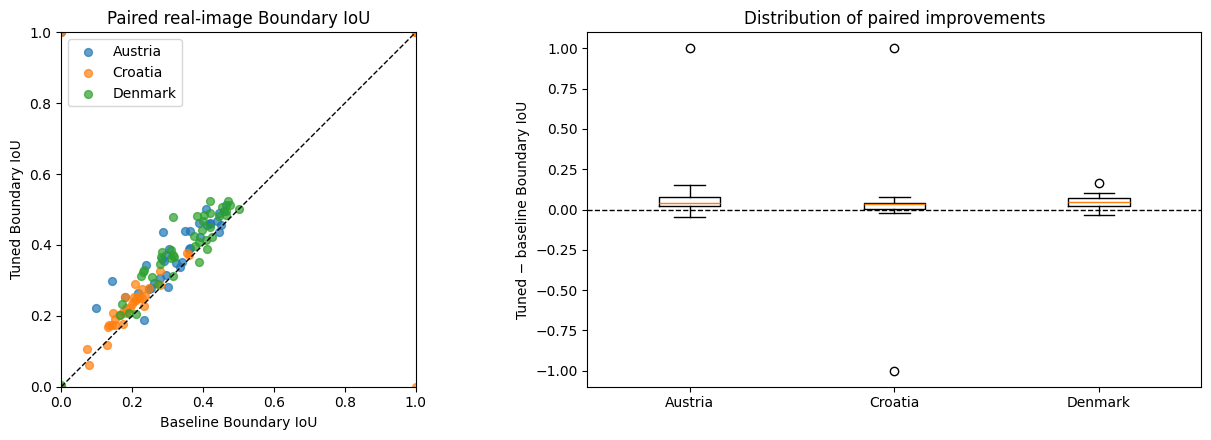

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for country, frame in results.groupby("country", sort=False):
    axes[0].scatter(
        frame["baseline_boundary_iou"], frame["tuned_boundary_iou"],
        s=32, alpha=0.7, label=country.title()
    )
axes[0].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[0].set(
    xlim=(0, 1), ylim=(0, 1), aspect="equal",
    xlabel="Baseline Boundary IoU", ylabel="Tuned Boundary IoU",
    title="Paired real-image Boundary IoU",
)
axes[0].legend()

delta_data = [
    results.loc[results.country == country, "boundary_iou_delta"]
    for country in COUNTRIES
]
axes[1].boxplot(delta_data, tick_labels=[c.title() for c in COUNTRIES], showfliers=True)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set(
    ylabel="Tuned − baseline Boundary IoU",
    title="Distribution of paired improvements",
)
fig.tight_layout()
plt.show()

### 6. Inspect identical real images side by side

The first column is a contrast-stretched RGB view of Sentinel-2 window B. White outlines
show boundaries. In the overlay columns, cyan is ground truth, magenta is prediction,
and white is overlap. The chosen images are fixed before inference.

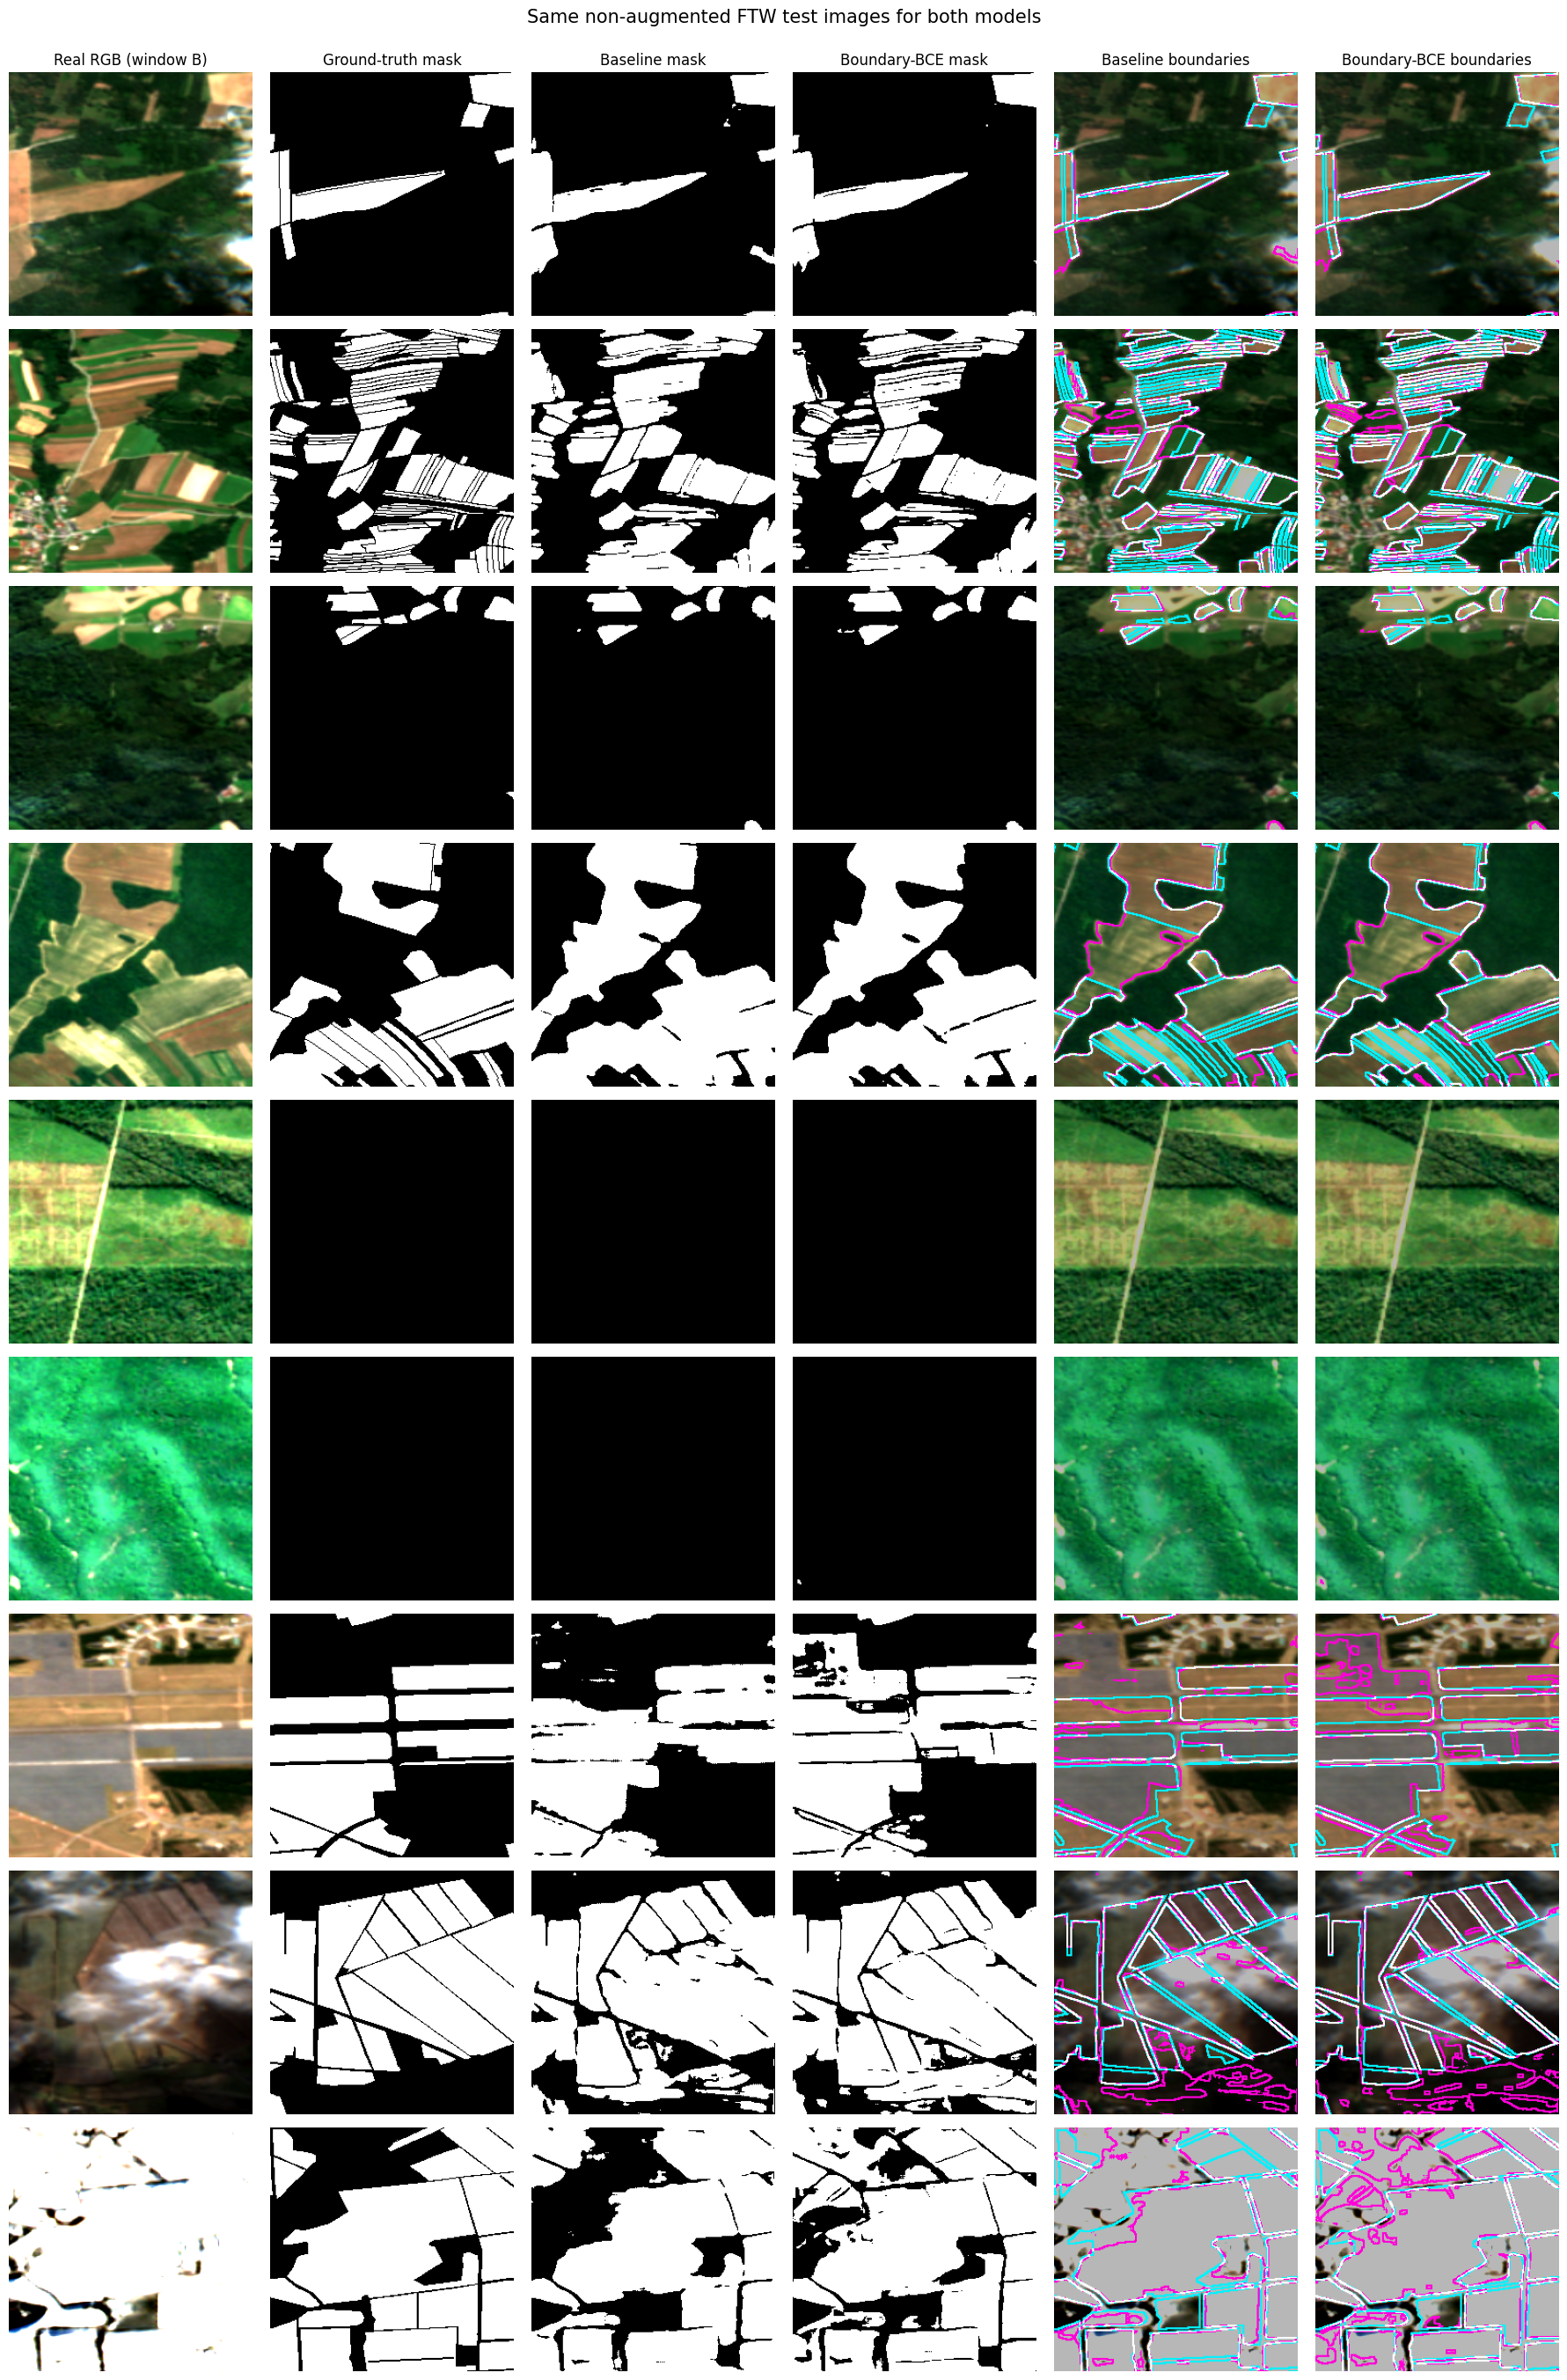

In [8]:
def rgb_for_display(image):
    rgb = image[:3].permute(1, 2, 0).cpu().numpy()
    low, high = np.percentile(rgb, [2, 98])
    return np.clip((rgb - low) / max(high - low, 1e-6), 0, 1)


def boundary_overlay(rgb, target_boundary, pred_boundary):
    overlay = rgb.copy() * 0.72
    target = target_boundary.astype(bool)
    prediction = pred_boundary.astype(bool)
    overlay[target] = [0.0, 0.95, 1.0]       # cyan: target
    overlay[prediction] = [1.0, 0.0, 0.85]   # magenta: prediction
    overlay[target & prediction] = [1.0, 1.0, 1.0]  # white: overlap
    return overlay


def predict_one(sample):
    image = sample["image"].unsqueeze(0).to(DEVICE)
    predictions = {}
    with torch.inference_mode():
        for name, model in models.items():
            predictions[name] = (
                torch.sigmoid(model(image)["mask_logits"])[0, 0] > THRESHOLD
            ).float().cpu()
    return predictions


fig, axes = plt.subplots(
    len(visual_dataset_indices), 6,
    figsize=(18, 3.0 * len(visual_dataset_indices)),
    squeeze=False,
)
for row_index, dataset_index in enumerate(visual_dataset_indices):
    sample = dataset[dataset_index]
    rgb = rgb_for_display(sample["image"])
    target = sample["mask"][0].float()
    target_boundary = mask_boundary(target[None, None], BOUNDARY_RADIUS)[0, 0].numpy()
    predictions = predict_one(sample)
    baseline = predictions["Mask baseline"]
    tuned = predictions["Boundary BCE w20 s012"]
    baseline_boundary = mask_boundary(baseline[None, None], BOUNDARY_RADIUS)[0, 0].numpy()
    tuned_boundary = mask_boundary(tuned[None, None], BOUNDARY_RADIUS)[0, 0].numpy()

    panels = [
        (rgb, "Real RGB (window B)"),
        (target.numpy(), "Ground-truth mask"),
        (baseline.numpy(), "Baseline mask"),
        (tuned.numpy(), "Boundary-BCE mask"),
        (boundary_overlay(rgb, target_boundary, baseline_boundary), "Baseline boundaries"),
        (boundary_overlay(rgb, target_boundary, tuned_boundary), "Boundary-BCE boundaries"),
    ]
    for column_index, (panel, title) in enumerate(panels):
        axes[row_index, column_index].imshow(panel, cmap="gray" if panel.ndim == 2 else None)
        axes[row_index, column_index].axis("off")
        if row_index == 0:
            axes[row_index, column_index].set_title(title)
    axes[row_index, 0].set_ylabel(sample["id"], rotation=0, ha="right", va="center")

fig.suptitle("Same non-augmented FTW test images for both models", y=1.0, fontsize=15)
fig.tight_layout()
plt.show()

### 7. Inspect strongest gains and regressions without hiding either

This table is diagnostic. It deliberately shows both tails of the paired delta rather
than only examples favorable to the tuned model.

In [9]:
columns = [
    "id", "baseline_boundary_iou", "tuned_boundary_iou", "boundary_iou_delta",
    "baseline_mask_iou", "tuned_mask_iou", "mask_iou_delta",
]
largest_gains = results.nlargest(5, "boundary_iou_delta")[columns]
largest_regressions = results.nsmallest(5, "boundary_iou_delta")[columns]
print("Largest Boundary IoU gains")
display(largest_gains.round(4))
print("Largest Boundary IoU regressions")
display(largest_regressions.round(4))

Largest Boundary IoU gains


,id,baseline_boundary_iou,tuned_boundary_iou,boundary_iou_delta,baseline_mask_iou,tuned_mask_iou,mask_iou_delta
46,croatia/g14-2_00047_12,0.0000,1.0000,1.0000,0.0000,1.0000,1.0000
19,austria/g94_00048_1,0.0000,1.0000,1.0000,0.0000,1.0000,1.0000
112,denmark/g22_00065_14,0.3154,0.4778,0.1624,0.7916,0.8288,0.0372
38,austria/g83_00044_17,0.1432,0.2983,0.1551,0.3304,0.6270,0.2966
26,austria/g95_00013_9,0.2872,0.4355,0.1483,0.4123,0.8563,0.4440


Largest Boundary IoU regressions


,id,baseline_boundary_iou,tuned_boundary_iou,boundary_iou_delta,baseline_mask_iou,tuned_mask_iou,mask_iou_delta
70,croatia/g10-3_00086_16,1.0000,0.0000,-1.0000,1.0000,0.0000,-1.0000
15,austria/g83_00003_15,0.2334,0.1877,-0.0457,0.7208,0.8127,0.0919
99,denmark/g22_00063_13,0.3878,0.3516,-0.0362,0.9686,0.9615,-0.0072
95,denmark/g6_00030_13,0.4119,0.3896,-0.0223,0.6107,0.5989,-0.0119
18,austria/g78_00034_10,0.3016,0.2819,-0.0198,0.4903,0.5014,0.0111


## Takeaways

- Use the paired summary and confidence interval—not a few favorable images—to decide
  whether `ftw_dual_head_boundary_bce_w20_s012` improves Boundary IoU.
- Check each country separately; an aggregate gain can hide a country-level regression.
- Compare Mask IoU alongside Boundary IoU to detect a boundary/interior trade-off.
- For the strongest final test, set `EVAL_SAMPLES_PER_COUNTRY = None` and rerun all cells.
- This is a checkpoint comparison on held-out observational imagery. It supports a
  performance claim for these data and settings, not a universal causal claim.